# 06 Hybrid approach - Dataset 3

Combines **centrality** + **embeddings** into a hybrid prediction, for each default threshold `p`. Two blends are built:

- **Average** - the simple mean of the two predictions.
- **Weighted average** - a data-driven blend: a linear regression learns weights on the **validation** split (`pred = a*centrality + b*embeddings + c`) and applies them on **test**. A weaker predictor automatically gets a smaller weight. (This is what "stacking" usually means.)

Reads the per-dataset threshold predictions; writes to `predictions/dataset_3/hybrid_approach/`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / 'src').exists() and (p / 'requirements.txt').exists():
            return p
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = find_project_root()
PRED = PROJECT_ROOT / 'src' / 'data' / 'predictions'
OUT  = PRED / 'dataset_3' / 'hybrid_approach'; OUT.mkdir(parents=True, exist_ok=True)
TC = 'log_systemic_risk_label'
DATASETS = ['dataset_3']
P_LIST = ['p0', 'p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']
rmse = lambda a, b: mean_squared_error(a, b) ** 0.5

## Build weighted average + average ensembles per dataset / p

In [2]:
rows, all_preds = [], []
for ds in DATASETS:
    cen = pd.read_csv(PRED / ds / 'centrality_threshold' / 'predictions.csv')
    emb = pd.read_csv(PRED / ds / 'embedding_threshold' / 'predictions.csv')
    for p in P_LIST:
        c = cen[cen.p == p][['bank_id', 'split', TC, 'prediction']].rename(columns={'prediction': 'centrality_pred'})
        e = emb[emb.p == p][['bank_id', 'split', 'prediction']].rename(columns={'prediction': 'embedding_pred'})
        m = c.merge(e, on=['bank_id', 'split'], how='inner')
        val, test = m[m.split == 'validation'], m[m.split == 'test'].copy()
        stk = LinearRegression().fit(val[['centrality_pred', 'embedding_pred']], val[TC])
        test['average_pred'] = test[['centrality_pred', 'embedding_pred']].mean(axis=1)
        test['stacked_pred'] = stk.predict(test[['centrality_pred', 'embedding_pred']])
        y = test[TC]
        rows.append({'dataset': ds, 'p': p,
                     'centrality_rmse': rmse(y, test.centrality_pred),
                     'embedding_rmse':  rmse(y, test.embedding_pred),
                     'average_rmse':    rmse(y, test.average_pred),
                     'stacked_rmse':    rmse(y, test.stacked_pred),
                     'centrality_mae':  mean_absolute_error(y, test.centrality_pred),
                     'embedding_mae':   mean_absolute_error(y, test.embedding_pred),
                     'average_mae':     mean_absolute_error(y, test.average_pred),
                     'stacked_mae':     mean_absolute_error(y, test.stacked_pred)})
        test['dataset'] = ds; test['p'] = p; all_preds.append(test)

metrics = pd.DataFrame(rows)
metrics.to_csv(OUT / 'metrics.csv', index=False)
pd.concat(all_preds, ignore_index=True).to_csv(OUT / 'predictions.csv', index=False)
print('saved ->', OUT)
display(metrics.round(3))

saved -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/dataset_3/hybrid_approach


,dataset,p,centrality_rmse,embedding_rmse,average_rmse,stacked_rmse,centrality_mae,embedding_mae,average_mae,stacked_mae
0,dataset_3,p0,0.329,0.694,0.435,0.327,0.145,0.455,0.264,0.167
1,dataset_3,p5,0.294,0.692,0.407,0.287,0.130,0.457,0.254,0.146
2,dataset_3,p10,0.294,0.702,0.415,0.289,0.130,0.466,0.263,0.151
3,dataset_3,p15,0.294,0.700,0.412,0.287,0.130,0.459,0.258,0.149
4,dataset_3,p20,0.325,0.734,0.445,0.317,0.135,0.467,0.266,0.154
5,dataset_3,p25,0.325,0.752,0.456,0.319,0.135,0.483,0.278,0.156
6,dataset_3,p30,0.325,0.763,0.459,0.318,0.135,0.483,0.274,0.151
7,dataset_3,p35,0.325,0.745,0.452,0.318,0.135,0.475,0.272,0.152
8,dataset_3,p40,0.325,0.734,0.449,0.318,0.135,0.461,0.264,0.150


## Test error across thresholds (same colours / plot names as Dataset 1)

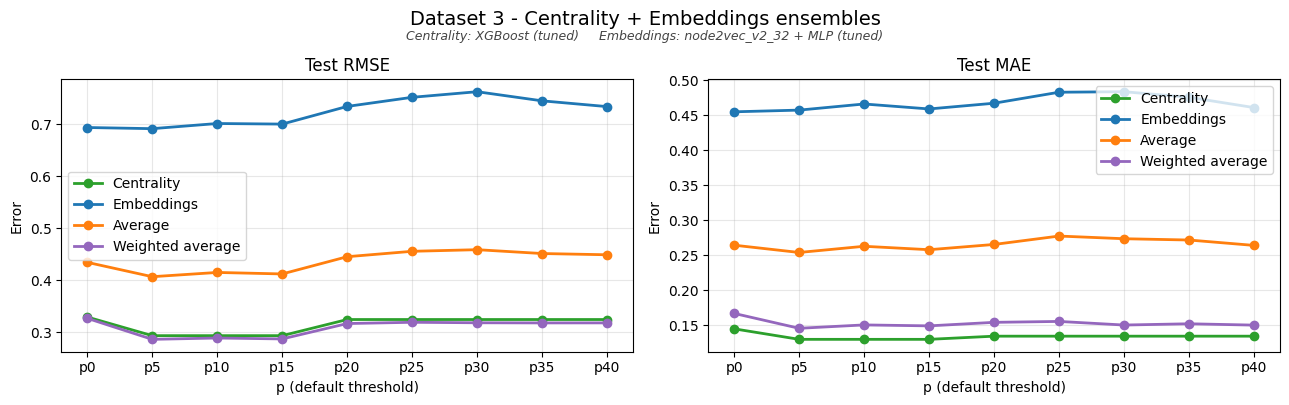

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/dataset_3/hybrid_approach/dataset_3_ensemble_comparison.png


,p,best_test_rmse_method,best_test_rmse
0,p0,Weighted average,0.327
1,p5,Weighted average,0.287
2,p10,Weighted average,0.289
3,p15,Weighted average,0.287
4,p20,Weighted average,0.317
5,p25,Weighted average,0.319
6,p30,Weighted average,0.318
7,p35,Weighted average,0.318
8,p40,Weighted average,0.318


In [3]:
# Same colour scheme and plot names/descriptions as Dataset 1's ensemble notebook.
METHOD_COLORS = {
    'Centrality': '#2ca02c',
    'Embeddings': '#1f77b4',
    'Average':    '#ff7f0e',
    'Weighted average':    '#9467bd',
}
METHOD_COLS = {
    'Centrality': ('centrality_rmse', 'centrality_mae'),
    'Embeddings': ('embedding_rmse',  'embedding_mae'),
    'Average':    ('average_rmse',    'average_mae'),
    'Weighted average':    ('stacked_rmse',    'stacked_mae'),
}
METRIC_PANELS = [(0, 'Test RMSE'), (1, 'Test MAE')]

# The model combination behind each base approach (centrality model | embedding + ML model).
MODEL_DESC = 'Centrality: XGBoost (tuned)     Embeddings: node2vec_v2_32 + MLP (tuned)'


def plot_dataset_ensemble(metrics_df, ds):
    d = metrics_df[metrics_df['dataset'] == ds].set_index('p').loc[P_LIST]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for ax, (idx, metric_title) in zip(axes.ravel(), METRIC_PANELS):
        for method, cols in METHOD_COLS.items():
            ax.plot(d.index, d[cols[idx]], marker='o', linewidth=2,
                    label=method, color=METHOD_COLORS[method])
        ax.set_title(metric_title)
        ax.set_xlabel('p (default threshold)')
        ax.set_ylabel('Error')
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    fig.suptitle(f'{ds.replace("_", " ").title()} - Centrality + Embeddings ensembles', fontsize=14, y=1.0)
    fig.text(0.5, 0.95, MODEL_DESC, ha='center', va='top', fontsize=9, style='italic', color='#444444')
    out_path = OUT / f'{ds}_ensemble_comparison.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {out_path}')


def winner_table(metrics_df, ds):
    d = metrics_df[metrics_df['dataset'] == ds].set_index('p').loc[P_LIST]
    rows = []
    for p in P_LIST:
        rmse_by_method = {m: d.loc[p, cols[0]] for m, cols in METHOD_COLS.items()}
        best = min(rmse_by_method, key=rmse_by_method.get)
        rows.append({'p': p, 'best_test_rmse_method': best, 'best_test_rmse': rmse_by_method[best]})
    return pd.DataFrame(rows).round(3)


for ds in DATASETS:
    plot_dataset_ensemble(metrics, ds)
    display(winner_table(metrics, ds))

## Validation vs test error by model

A compact view of each model's **validation** and **test** error (mean over the `p` thresholds), as a small table plus grouped bar plots. Note: the *Weighted average* stack is fit on the validation split, so its validation score is in-sample (optimistic); the other three are held-out on both splits.

dataset_3 - validation vs test (mean over p)


,val_rmse,test_rmse,val_mae,test_mae
model,,,,
Centrality,0.316,0.315,0.136,0.134
Embeddings,0.729,0.724,0.477,0.467
Average,0.437,0.437,0.272,0.266
Weighted average,0.310,0.309,0.155,0.153


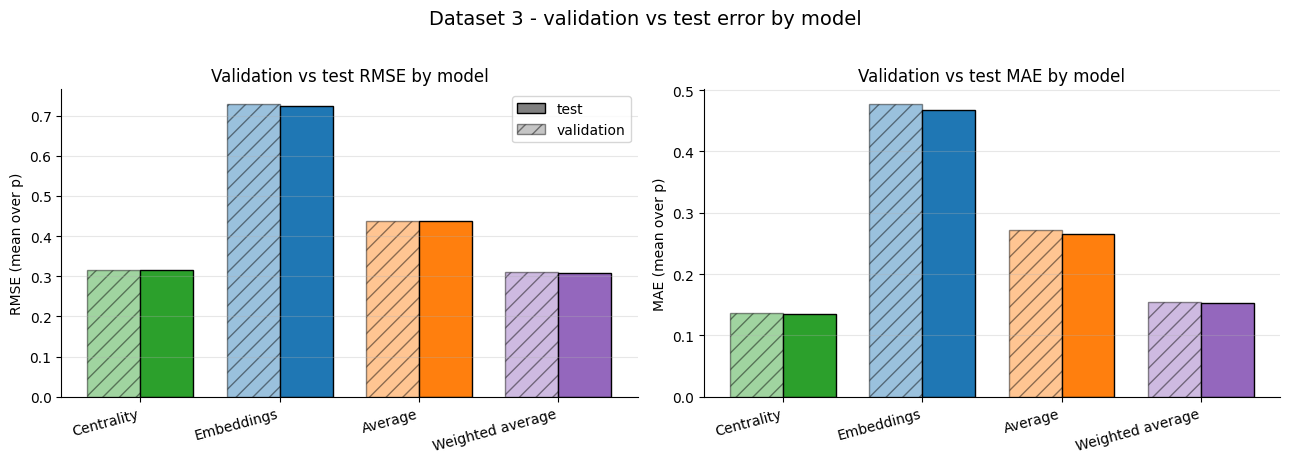

In [4]:
from matplotlib.patches import Patch

# Validation + test metrics per model, per p (same merge/stack logic as the cell above).
vt_rows = []
for ds in DATASETS:
    cen = pd.read_csv(PRED / ds / 'centrality_threshold' / 'predictions.csv')
    emb = pd.read_csv(PRED / ds / 'embedding_threshold' / 'predictions.csv')
    for p in P_LIST:
        c = cen[cen.p == p][['bank_id', 'split', TC, 'prediction']].rename(columns={'prediction': 'centrality_pred'})
        e = emb[emb.p == p][['bank_id', 'split', 'prediction']].rename(columns={'prediction': 'embedding_pred'})
        m = c.merge(e, on=['bank_id', 'split'], how='inner')
        val, test = m[m.split == 'validation'].copy(), m[m.split == 'test'].copy()
        if val.empty or test.empty:
            continue
        stk = LinearRegression().fit(val[['centrality_pred', 'embedding_pred']], val[TC])
        for split_name, d in [('validation', val), ('test', test)]:
            d = d.copy()
            d['average_pred'] = d[['centrality_pred', 'embedding_pred']].mean(axis=1)
            d['stacked_pred'] = stk.predict(d[['centrality_pred', 'embedding_pred']])
            y = d[TC]
            for method, col in [('Centrality', 'centrality_pred'), ('Embeddings', 'embedding_pred'),
                                ('Average', 'average_pred'), ('Weighted average', 'stacked_pred')]:
                vt_rows.append({'dataset': ds, 'method': method, 'split': split_name,
                                'rmse': rmse(y, d[col]), 'mae': mean_absolute_error(y, d[col])})

valtest = pd.DataFrame(vt_rows)
methods = ['Centrality', 'Embeddings', 'Average', 'Weighted average']

for ds in DATASETS:
    agg = valtest[valtest['dataset'] == ds].groupby(['method', 'split'])[['rmse', 'mae']].mean()

    val_test_table = pd.DataFrame({
        'val_rmse':  [agg.loc[(m, 'validation'), 'rmse'] for m in methods],
        'test_rmse': [agg.loc[(m, 'test'),       'rmse'] for m in methods],
        'val_mae':   [agg.loc[(m, 'validation'), 'mae']  for m in methods],
        'test_mae':  [agg.loc[(m, 'test'),       'mae']  for m in methods],
    }, index=methods).round(3)
    val_test_table.index.name = 'model'
    print(f'{ds} - validation vs test (mean over p)')
    display(val_test_table)

    x = np.arange(len(methods)); w = 0.38
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, (metric, mtitle) in zip(axes, [('rmse', 'RMSE'), ('mae', 'MAE')]):
        for i, method in enumerate(methods):
            col = METHOD_COLORS[method]
            ax.bar(x[i] - w / 2, agg.loc[(method, 'validation'), metric], w, color=col,
                   edgecolor='black', alpha=0.45, hatch='//')
            ax.bar(x[i] + w / 2, agg.loc[(method, 'test'), metric], w, color=col, edgecolor='black')
        ax.set_xticks(x); ax.set_xticklabels(methods, rotation=15, ha='right')
        ax.set_ylabel(f'{mtitle} (mean over p)'); ax.set_title(f'Validation vs test {mtitle} by model')
        ax.grid(True, axis='y', alpha=0.3)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
    axes[0].legend(handles=[Patch(facecolor='gray', edgecolor='black', label='test'),
                            Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='//', label='validation')])
    fig.suptitle(f'{ds.replace("_", " ").title()} - validation vs test error by model', fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(OUT / f'{ds}_val_test_by_model.png', dpi=150, bbox_inches='tight')
    plt.show()